<img src="logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# Trabajo semanal 0
#### Piantadosi Alejandro


## Introducción
En este primer trabajo semanal del año nos centraremos en la resolucion de un filtro activo de primer orden, en el cual trabajaremos los conceptos de transferencia, respuestas de modulo y fase, diagramas de polos y ceros, escalado y normalizacion de circuitos y ademas lo utilizaremos como introduccion practica a la simulacion numerica y circuital utilizando nuevas herramientas propias de la materia como lo son; Lt Spice, simulacion con Python, Spyder, etc.


## Filtro activo

<img src="PasaTodo.png" align="center" width="500" /> 

### 1- Transferencia 
\begin{equation} H(s) = \frac{V2}{V1}\end{equation} 

Para comenzar con este analisis empezaremos aplicando la ley de corrientes de Kirchoff en el nodo V- del operacional, al cual denominaremos Vx.


\begin{equation} Vx.(Y1+Y2)-V1.Y1-V2.Y2=0   (1)\end{equation} 

Este ultimo coincide con la tension en V+ del operacional ya que se trata de un OpAmp ideal, en el cual asumimos el puente virtual. Dejandonos asi, la ecuacion de corrientes en el nodo V- de la siguiente forma:

\begin{equation} Vx.(Y3+sC1)-V1.sC1=0\end{equation} 

de la cual obtenemos

\begin{equation} Vx=V1.\frac{sC1}{Y3+sC1}  (2)\end{equation} 

Finalmente reemplazamos Vx(2) en la ecuacion nodal(1)

\begin{equation} V1.\frac{sC1}{Y3+sC1}.(Y1+Y2)-V1.Y1-V2.Y2=0 \end{equation}

Llegando asi, luego del trabajo algebraico a la funcion transferencia:

\begin{equation} H(s) = \frac{V2}{V1} = \frac{s-\frac{Y1.Y3}{C1.Y2}}{s+\frac{Y3}{C1}}\end{equation}

\begin{equation} H(s) = \frac{V2}{V1} = \frac{s-\frac{R2}{C1.R1.R3}}{s+\frac{1}{C1.R3}}\end{equation}

Notese que la transferencia lograda de este filtro de primer orden tiene la forma de un Filtro de fase, el cual dependiendo los valores de K logra comportarse como un Pasa-Todo en el caso que logremos K=1, generando la simetria sobre el eje real de los polos respecto a los ceros, logrando mantener un nivel constante, pero ademas invertir la fase en w0. Luego en caso de que K sea distinto de 1 se logra "adelantar" (K>1) o "atrasar" el cambio de fase (K<1) respecto al de nuestro w0 inicial, ademas en cuanto a las particularidades de modulo para estos casos, se logra atenuar o resaltar los agudos respectivamente.


\begin{equation} K = \frac{R2}{R1}\end{equation} 

\begin{equation} w0 = \frac{1}{C1.R3}\end{equation} 

\begin{equation} H(s) =\frac{s-\frac{K}{C1.R3}}{s+\frac{1}{C1.R3}} = \frac{s-K.w0}{s+w0}\end{equation}

### Obtencion de diagramas; Polos y ceros, y Bode:

Suponiendo K=1, es decir R2=R1, procedemos a obtener las normas de frecuencia e impedancia para obtener una red normalizada en w0=1

#### Normalizacion en Frecuencia:

\begin{equation} w´= w.w0\end{equation}  \begin{equation} s´= s.w0\end{equation} 

\begin{equation} T(s´)= \frac{s.w0-w0}{sw0+w0}=\frac{s-1}{s+1}\end{equation}
 
\begin{equation} Nw=w0=\frac{1}{C1.R3}=1\end{equation} \begin{equation} C1=\frac{1}{R3}\end{equation}

#### Normalizacion en Impedancia:
\begin{equation} Nz=R3\end{equation} \begin{equation} R3´=\frac{R3}{R3}=1\end{equation} \begin{equation} R2´=\frac{R2}{R3}\end{equation}
\begin{equation} R1´=\frac{R1}{R3}\end{equation}\begin{equation} ZC´=\frac{1}{sC.R3}\end{equation}

#### Normalizacion Conjunta:
\begin{equation}C´=C1.Nz.Nw0\frac{C1.R3}{C.R3}=1\end{equation}
\begin{equation} R3´=\frac{R3}{R3}=1\end{equation} \begin{equation} R2´=\frac{R2}{R3}\end{equation}
\begin{equation} R1´=\frac{R1}{R3}\end{equation}

Con R2´= R1':

\begin{equation} R2´=\frac{R2}{R3}= R1´=\frac{R1}{R3}\end{equation}
\begin{equation} R2=R3 end{equation}

Lo que nos deja un pasa todo de w0=1.
\begin{equation} T(s)= \frac{s-1}{s+1}\end{equation}

##### Y ahora si con los valores obtenidos realizamos la simulacion numerica

In [1]:
# PyTC2: La librería para TC2
from pytc2.sistemas_lineales import pzmap, GroupDelay, bodePlot

from scipy.signal import TransferFunction
import numpy as np
import matplotlib.pyplot as plt


# las librerías que usarremos las cargamos solo una vez.

In [2]:

# Esta parte de código la agregamos SOLO en los notebooks para fijar el estilo de los gráficos.
#
#%%  Inicialización de librerías (esto NO es parte del script demo_seg_orden1.py)
# Setup inline graphics: Esto lo hacemos para que el tamaño de la salida, 
# sea un poco más adecuada al tamaño del jupyter notebook documento

# algún bug cuando lo hice:
plt.figure(1)
plt.close(1)

import matplotlib as mpl

fig_sz_x = 13
fig_sz_y = 5
fig_dpi = 80 # dpi
fig_font_size = 13

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

#%%  Fin - Inicialización de librerías



(2, <Axes: xlabel='$\\sigma$', ylabel='j$\\omega$'>)

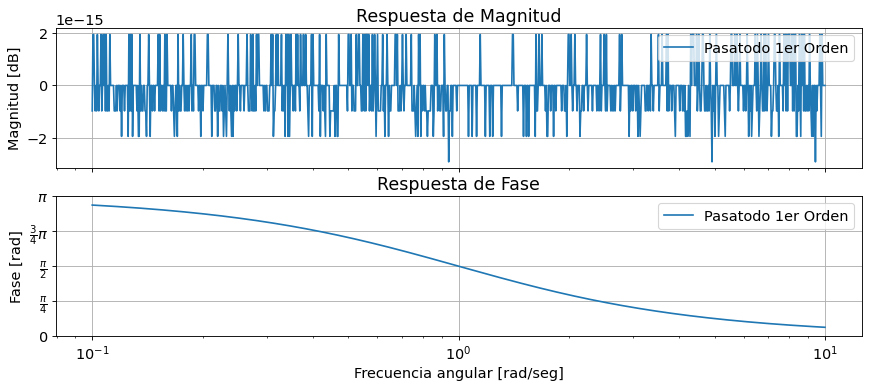

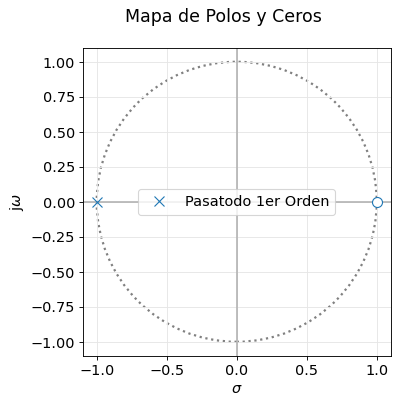

In [3]:
# El código en sí, lo puedo modificar y re-ejecutar tantas veces como quiera
R1=1
R2=1
R3=1
C1=1 
w0 = 1/(R3*C1)
K = R2/R1

my_tf = TransferFunction( [1,-1*K*w0], [1, w0] )

bodePlot(my_tf, fig_id=1, filter_description = 'Pasatodo 1er Orden')

pzmap(my_tf, fig_id=2, filter_description = 'Pasatodo 1er Orden') #S plane pole/zero plot


Como podemos observar logramos un pasa todo de primer grado, logrando ver la simetria en el plano s, el cambio de fase sobre w0=1000 y manteniendo un modulo constante en 0dB (Los picos observados son pequeños errores de calculo de la maquina al realizar las operaciones discretas)


# Comprobacion por LtSpice

Para completar con esta tarea, realizamos la simulacion circuital, armando el disño planteado, agregandole la fuente de alimentacion partida al OpAmp para su correcto funcionamiento y comparamos frecuencialmente en una escala de decadas, la salida respecto de la entrada.

Esto fue lo que obtuvimos:


<img src="EsquematicoLT.png" align="center" width="1000" /> 
<img src="BodeLT.png" align="center" width="1000" /> 

En este caso podemos observar el cruce por 90°en el caso de la fase, en la frecuencia seleccionada f0=10KHz, pero ademas logramos ver las deficiencias reales del OpAmp, observando su decaimiento en nivel al alcanzar la frecuencia maxima de trabajo del mismo.


### Comparativa con circuito planteado

Se nos pide analizar el caso de  MF-103 y lograr observar que funcione de la misma forma.

<img src="MF-103.png" align="center" width="1000" /> 

En este mismo vemos una serie en cadena de los bloques PasaTodo mostrados anteriormente, logrando un encadenamiento de hasta 12 bloques.
Si bien ambos circuitos funcionan de la misma forma en cuanto a que son bloques de desplazamiento de fase. La red del MF-103 es una versión más compleja y versátil (activa y controlada por corriente/tensión mediante OTAs y no mediante OpAmps) que permite el mismo procesamiento de señal que nuestro circuito implementado con Amplificadores operacionales.
